## INSTALL LIBRARIES

In [1]:
import sys

!{sys.executable} -m pip install -U pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import sklearn
import imblearn

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Imbalanced-learn:", imblearn.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Scikit-learn: 1.9.0
Imbalanced-learn: 0.14.2


## LOAD DATASET

In [4]:
df = pd.read_csv(r"C:\Users\pk706\Downloads\credit_card_fraud_10k.csv")

In [6]:
df.shape

(10000, 10)

In [7]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
df.columns.tolist()

['transaction_id',
 'amount',
 'transaction_hour',
 'merchant_category',
 'foreign_transaction',
 'location_mismatch',
 'device_trust_score',
 'velocity_last_24h',
 'cardholder_age',
 'is_fraud']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB


In [10]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [11]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


### check fraud distribution
#### 0 -> Legitimate Transaction
#### 1 -> Fraudulent Transaction

In [15]:
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


## FRAUD VS LEGITIMATE TRANSACTION

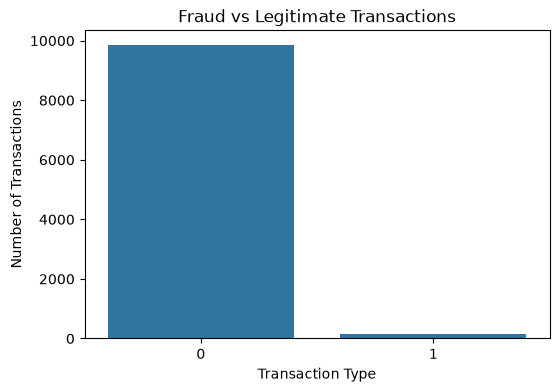

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

## Fraud percentage

In [17]:
fraud_percentage = df["is_fraud"].mean() * 100

print(f"Fraud Transaction Percentage: {fraud_percentage:.2f}%")

Fraud Transaction Percentage: 1.51%


## TRANSACTION AMOUNT DISTRIBUTION

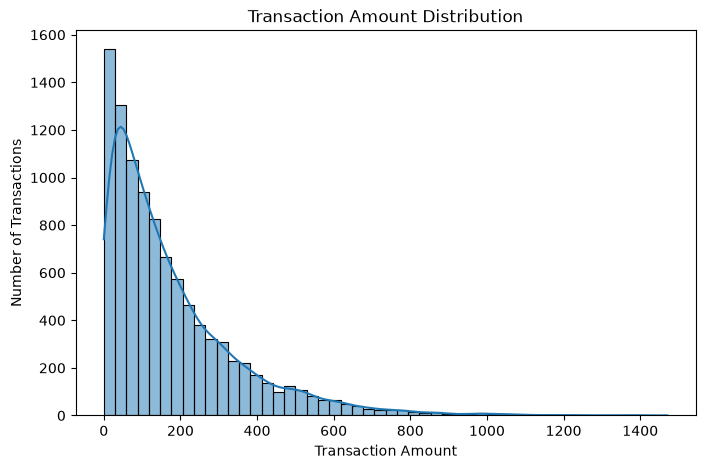

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="amount", bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

## AMOUNT BY FRAUD STATUS

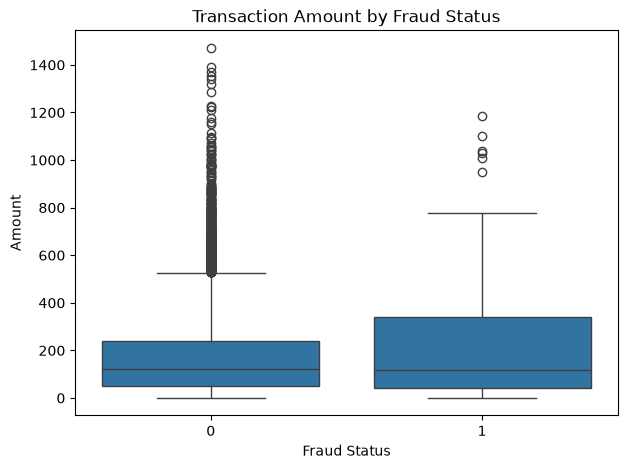

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="is_fraud", y="amount")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Amount")

plt.show()

## FRAUD BY TRANSACTION HOUR

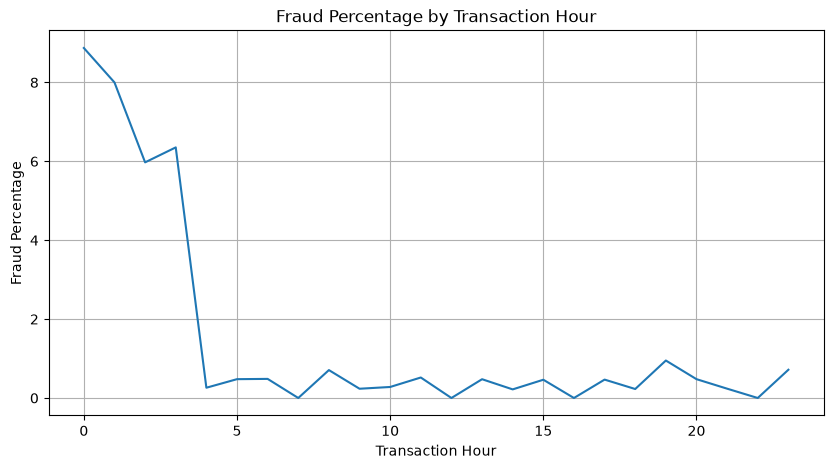

In [20]:
hour_fraud = df.groupby("transaction_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10,5))

hour_fraud.plot()

plt.title("Fraud Percentage by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Percentage")

plt.grid()
plt.show()

## FRAUD BY MERCHANT CATEGORY

In [21]:
merchant_fraud = pd.crosstab(
    df["merchant_category"],
    df["is_fraud"],
    normalize="index"
) * 100

print(merchant_fraud)

is_fraud                   0         1
merchant_category                     
Clothing           98.829268  1.170732
Electronics        98.751950  1.248050
Food               98.327759  1.672241
Grocery            97.993827  2.006173
Travel             98.542714  1.457286


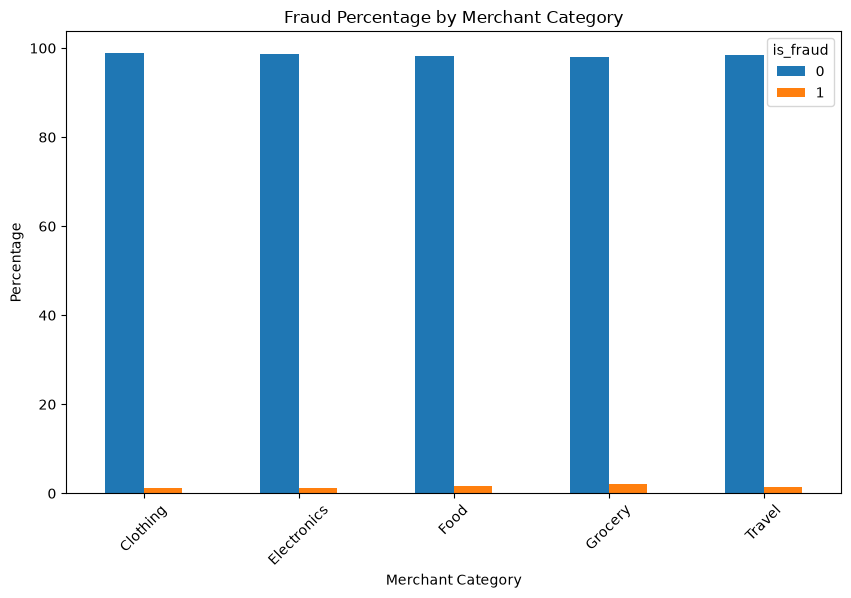

In [22]:
merchant_fraud.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Fraud Percentage by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.show()

## FOREIGN TRANSACTIONS VS FRAUD

In [23]:
foreign_fraud = pd.crosstab(
    df["foreign_transaction"],
    df["is_fraud"],
    normalize="index"
) * 100

print(foreign_fraud)

is_fraud                     0         1
foreign_transaction                     
0                    99.235203  0.764797
1                    91.615542  8.384458


## LOCATION MISMATCH VS FRAUD

In [24]:
location_fraud = pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
) * 100

print(location_fraud)

is_fraud                   0         1
location_mismatch                     
0                  99.135951  0.864049
1                  91.598600  8.401400


## DEVICE TRUST SCORE

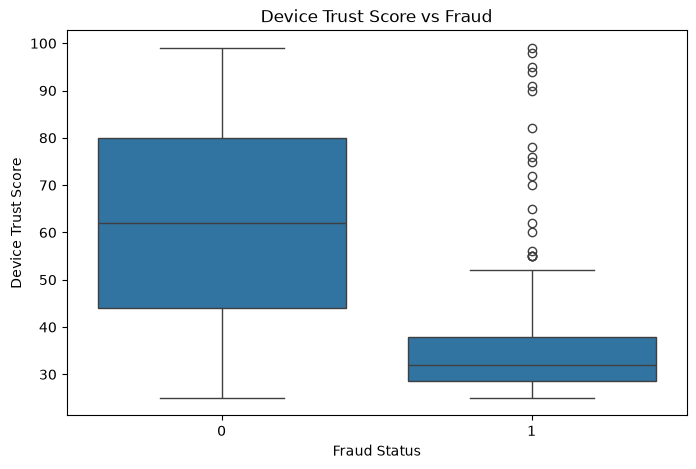

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="device_trust_score"
)

plt.title("Device Trust Score vs Fraud")
plt.xlabel("Fraud Status")
plt.ylabel("Device Trust Score")

plt.show()

## TRANSACTION VELOCITY

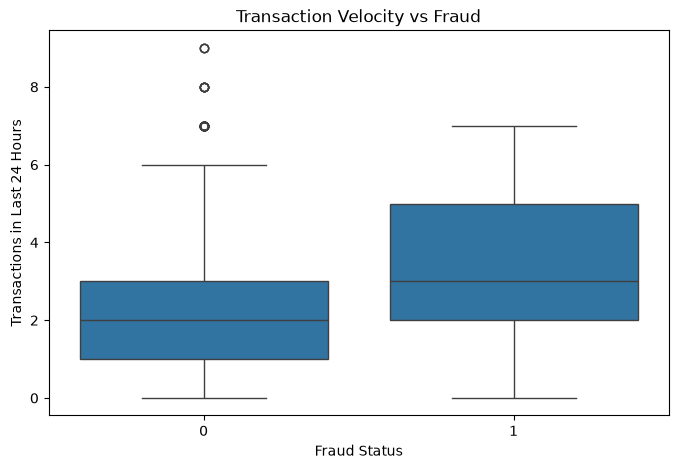

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="velocity_last_24h"
)

plt.title("Transaction Velocity vs Fraud")
plt.xlabel("Fraud Status")
plt.ylabel("Transactions in Last 24 Hours")

plt.show()

## CORRELATION HEATMAP

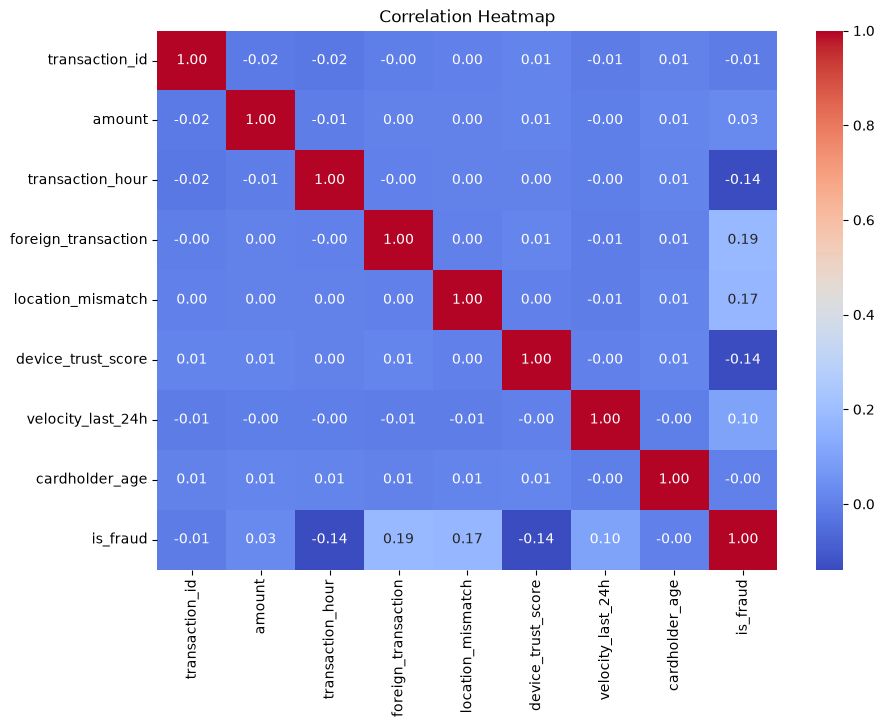

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## PREPARE FEATURES AND TARGET

In [28]:
X = df.drop(columns=["is_fraud", "transaction_id"])

y = df["is_fraud"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("is_fraud")

Features:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

Target:
is_fraud


## IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS

In [29]:
categorical_features = ["merchant_category"]

numerical_features = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

## TRAIN-TEST SPLIT

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 8)
Testing data: (2000, 8)


## PREPROCESSING

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

## LOGISTIC REGRESSION BASELINE

In [33]:
lr_model = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](8,)","['amount','transaction_hour','merchant_category',...,'device_trust_score', 'velocity_last_24h','cardholder_age']"
n_features_in_,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


## LOGISTIC REGRESSION PREDICTIONS

In [34]:
lr_pred = lr_model.predict(X_test)

lr_probability = lr_model.predict_proba(X_test)[:, 1]

### EVALUATION

In [35]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
lr_roc_auc = roc_auc_score(y_test, lr_probability)
lr_pr_auc = average_precision_score(y_test, lr_probability)

print("LOGISTIC REGRESSION")
print("--------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_roc_auc)
print("PR-AUC   :", lr_pr_auc)

LOGISTIC REGRESSION
--------------------------
Accuracy : 0.958
Precision: 0.25892857142857145
Recall   : 0.9666666666666667
F1 Score : 0.4084507042253521
ROC-AUC  : 0.9932825719120135
PR-AUC   : 0.7364463488041411


## CONFUSION MATRIX

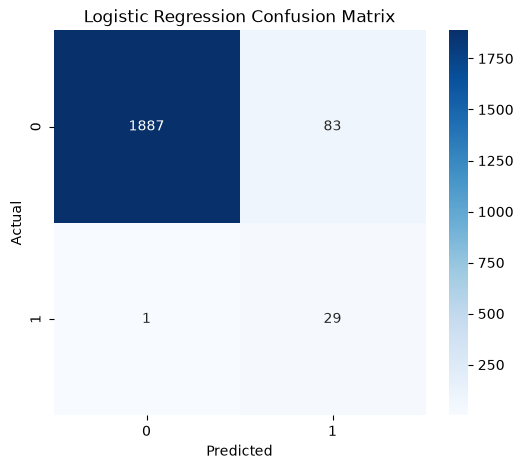

In [36]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## LOGISTIC REGRESSION CLASSIFICATION REPORT

In [37]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98      1970
       Fraud       0.26      0.97      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.96      0.69      2000
weighted avg       0.99      0.96      0.97      2000



## RANDOM FOREST MODEL

In [38]:
rf_model = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](8,)","['amount','transaction_hour','merchant_category',...,'device_trust_score', 'velocity_last_24h','cardholder_age']"
n_features_in_,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


## PREDICTIONS

In [39]:
rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(X_test)[:, 1]

## EVALUATION

In [40]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_probability)
rf_pr_auc = average_precision_score(y_test, rf_probability)

print("RANDOM FOREST")
print("--------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)
print("PR-AUC   :", rf_pr_auc)

RANDOM FOREST
--------------------------
Accuracy : 0.9985
Precision: 1.0
Recall   : 0.9
F1 Score : 0.9473684210526315
ROC-AUC  : 1.0
PR-AUC   : 1.0


## CONFUSION MATRIX

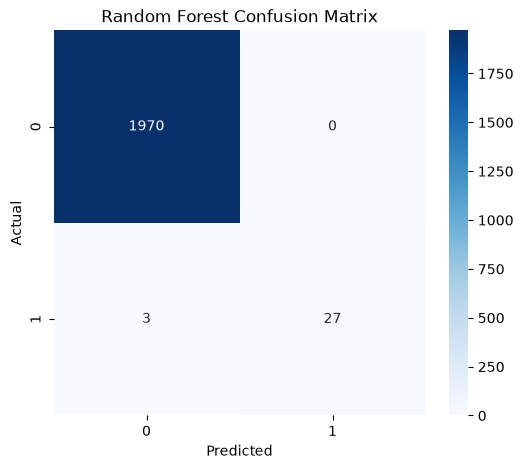

In [41]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## SMOTE

In [42]:
rf_smote_model = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_smote_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](8,)","['amount','transaction_hour','merchant_category',...,'device_trust_score', 'velocity_last_24h','cardholder_age']"
n_features_in_,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


## SMOTE RANDOM FOREST PREDICTIONS

In [43]:
rf_smote_pred = rf_smote_model.predict(X_test)

rf_smote_probability = rf_smote_model.predict_proba(X_test)[:, 1]

## EVALUATE SMOTE RANDOM FOREST

In [44]:
smote_accuracy = accuracy_score(y_test, rf_smote_pred)
smote_precision = precision_score(y_test, rf_smote_pred, zero_division=0)
smote_recall = recall_score(y_test, rf_smote_pred, zero_division=0)
smote_f1 = f1_score(y_test, rf_smote_pred, zero_division=0)
smote_roc_auc = roc_auc_score(y_test, rf_smote_probability)
smote_pr_auc = average_precision_score(y_test, rf_smote_probability)

print("RANDOM FOREST + SMOTE")
print("--------------------------")
print("Accuracy :", smote_accuracy)
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)
print("ROC-AUC  :", smote_roc_auc)
print("PR-AUC   :", smote_pr_auc)

RANDOM FOREST + SMOTE
--------------------------
Accuracy : 0.995
Precision: 1.0
Recall   : 0.6666666666666666
F1 Score : 0.8
ROC-AUC  : 0.9993401015228427
PR-AUC   : 0.9603686058305623


## COMPARE ALL MODELS

In [45]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest + SMOTE"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        smote_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        smote_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        smote_recall
    ],
    "F1": [
        lr_f1,
        rf_f1,
        smote_f1
    ],
    "ROC_AUC": [
        lr_roc_auc,
        rf_roc_auc,
        smote_roc_auc
    ],
    "PR_AUC": [
        lr_pr_auc,
        rf_pr_auc,
        smote_pr_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9580,0.258929,0.966667,0.408451,0.993283,0.736446
1,Random Forest,0.9985,1.000000,0.900000,0.947368,1.000000,1.000000
2,Random Forest + SMOTE,0.9950,1.000000,0.666667,0.800000,0.999340,0.960369


## ROC CURVES

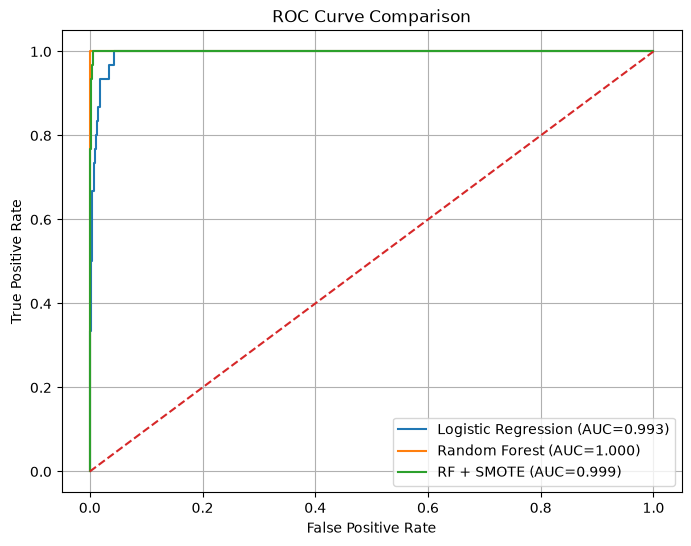

In [46]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probability)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probability)
smote_fpr, smote_tpr, _ = roc_curve(y_test, rf_smote_probability)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_roc_auc:.3f})"
)

plt.plot(
    smote_fpr,
    smote_tpr,
    label=f"RF + SMOTE (AUC={smote_roc_auc:.3f})"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.show()

## PRECISION RECALL CURVES

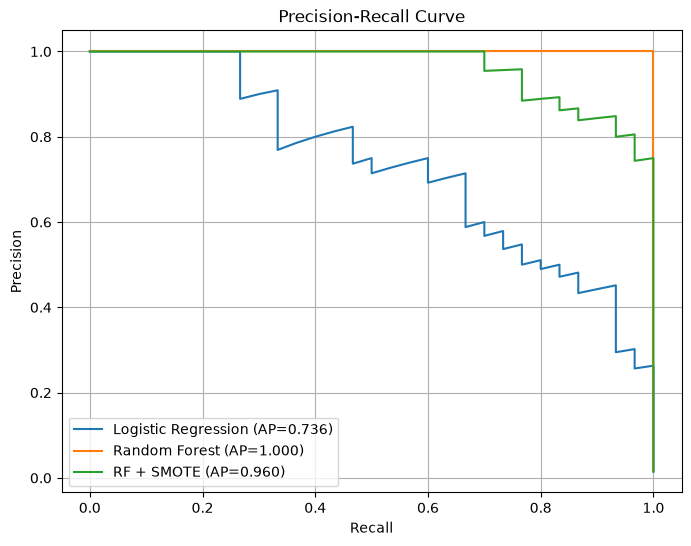

In [47]:
lr_precision_curve, lr_recall_curve, _ = precision_recall_curve(
    y_test,
    lr_probability
)

rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(
    y_test,
    rf_probability
)

smote_precision_curve, smote_recall_curve, _ = precision_recall_curve(
    y_test,
    rf_smote_probability
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_recall_curve,
    lr_precision_curve,
    label=f"Logistic Regression (AP={lr_pr_auc:.3f})"
)

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Random Forest (AP={rf_pr_auc:.3f})"
)
plt.plot(
    smote_recall_curve,
    smote_precision_curve,
    label=f"RF + SMOTE (AP={smote_pr_auc:.3f})"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid()

plt.show()

## FEATURE IMPORTANCE

In [48]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,num__transaction_hour,0.262959
4,num__device_trust_score,0.253340
2,num__foreign_transaction,0.143803
5,num__velocity_last_24h,0.130792
3,num__location_mismatch,0.116167
0,num__amount,0.045140
6,num__cardholder_age,0.025977
11,cat__merchant_category_Travel,0.005329
8,cat__merchant_category_Electronics,0.004961
7,cat__merchant_category_Clothing,0.004599


## PLOT FEATURE IMPORTANCE

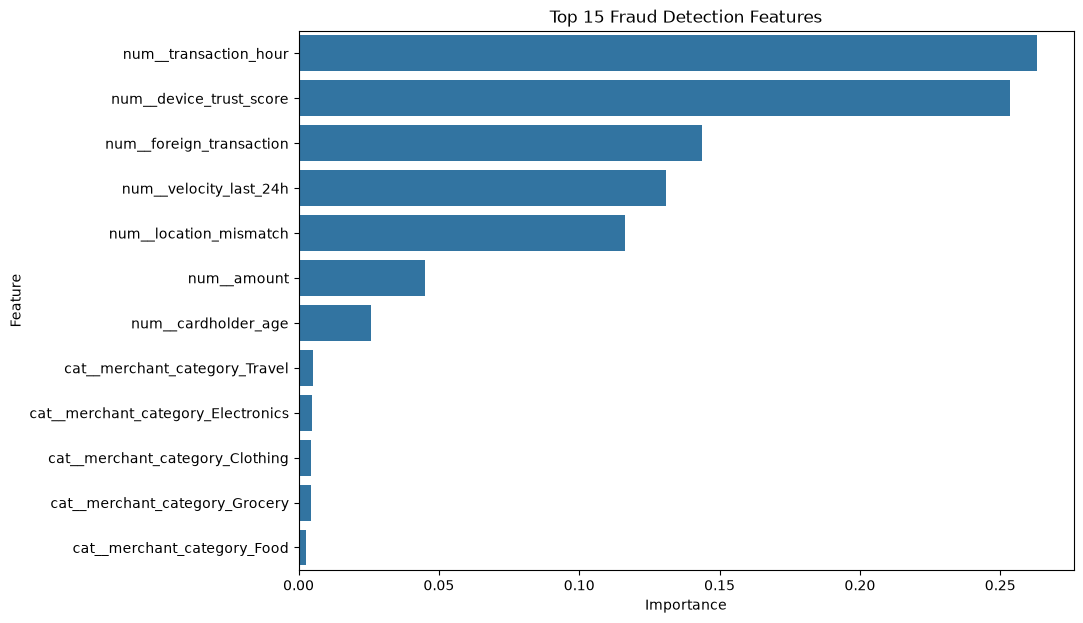

In [49]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Fraud Detection Features")

plt.show()

## THRESHOLD TUNING

In [50]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_smote_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.270270,1.000000,0.425532
1,0.15,0.379747,1.000000,0.550459
2,0.20,0.483871,1.000000,0.652174
3,0.25,0.600000,1.000000,0.750000
4,0.30,0.714286,1.000000,0.833333
5,0.35,0.800000,0.933333,0.861538
6,0.40,0.862069,0.833333,0.847458
7,0.45,0.958333,0.766667,0.851852
8,0.50,1.000000,0.666667,0.800000
9,0.55,1.000000,0.600000,0.750000


## FIND BEST THRESHOLD

In [51]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_row["F1"])

Best Threshold: 0.3500000000000001
Best F1 Score: 0.8615384615384616


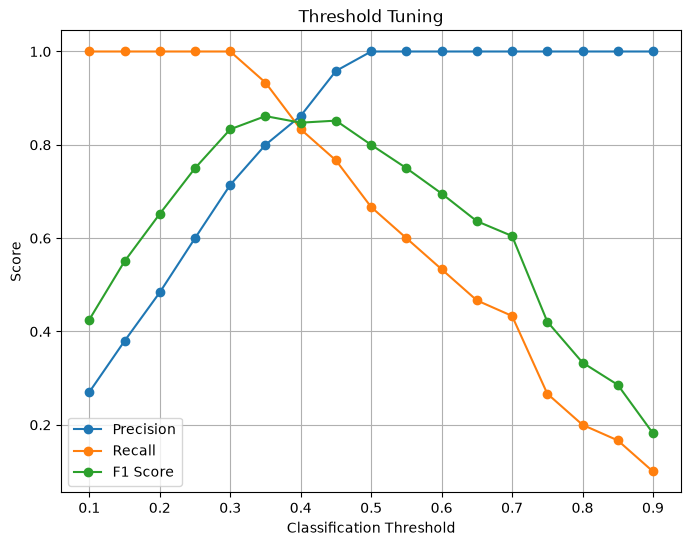

In [52]:
plt.figure(figsize=(8,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
     label="F1 Score"
)

plt.title("Threshold Tuning")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.legend()
plt.grid()

plt.show()

## FINAL PREDICTIONS

In [53]:
final_probability = rf_smote_probability

final_prediction = (
    final_probability >= best_threshold
).astype(int)

## FINAL EVALUATION

In [54]:
final_accuracy = accuracy_score(
    y_test,
    final_prediction
)

final_precision = precision_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_prediction,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probability
)

final_pr_auc = average_precision_score(
    y_test,
    final_probability
)

print("FINAL MODEL — RANDOM FOREST + SMOTE")
print("------------------------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)
print("PR-AUC   :", final_pr_auc)
print("Threshold:", best_threshold)

FINAL MODEL — RANDOM FOREST + SMOTE
------------------------------------
Accuracy : 0.9955
Precision: 0.8
Recall   : 0.9333333333333333
F1 Score : 0.8615384615384616
ROC-AUC  : 0.9993401015228427
PR-AUC   : 0.9603686058305623
Threshold: 0.3500000000000001


## FINAL CONFUSION MATRIX

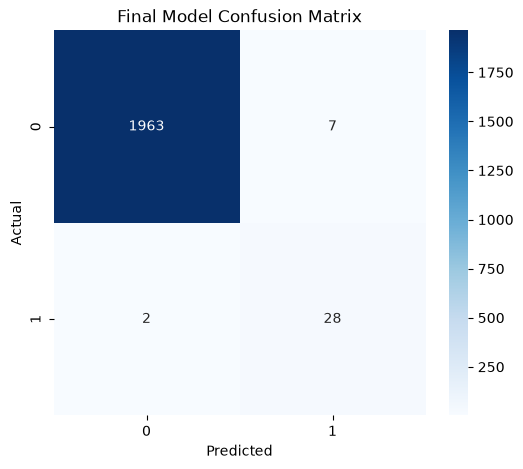

In [55]:
cm = confusion_matrix(
    y_test,
    final_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## CLASSIFICATION REPORT

In [56]:
print(
    classification_report(
        y_test,
        final_prediction,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       0.80      0.93      0.86        30

    accuracy                           1.00      2000
   macro avg       0.90      0.96      0.93      2000
weighted avg       1.00      1.00      1.00      2000



## RISK LEVELS

In [57]:
def risk_level(probability):

    if probability >= 0.80:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [58]:
risk_levels = [
    risk_level(prob)
    for prob in final_probability
]

## POWER BI DATASET

In [59]:
powerbi_results = df.loc[X_test.index].copy()

powerbi_results["Actual_Fraud"] = y_test.values

powerbi_results["Fraud_Probability"] = final_probability

powerbi_results["Predicted_Fraud"] = final_prediction

powerbi_results["Risk_Level"] = risk_levels

### add transaction status

In [60]:
powerbi_results["Transaction_Status"] = np.where(
    powerbi_results["Actual_Fraud"] == 1,
    "Fraud",
    "Legitimate"
)

### add prediction status

In [61]:
powerbi_results["Prediction_Status"] = np.where(
    powerbi_results["Predicted_Fraud"] == 1,
    "Fraud Predicted",
    "Legitimate Predicted"
)

### add fraud flag

In [62]:
powerbi_results["Fraud_Flag"] = np.where(
    powerbi_results["Predicted_Fraud"] == 1,
    "⚠ Fraud Alert",
    "✓ Normal"
)

## VIEW POWER BI RESULTS

In [63]:
powerbi_results.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,Actual_Fraud,Fraud_Probability,Predicted_Fraud,Risk_Level,Transaction_Status,Prediction_Status,Fraud_Flag
9944,9945,61.48,7,Clothing,0,0,45,3,46,0,0,0.000000,0,Low Risk,Legitimate,Legitimate Predicted,✓ Normal
2601,2602,10.06,20,Grocery,0,0,25,3,26,0,0,0.000154,0,Low Risk,Legitimate,Legitimate Predicted,✓ Normal
342,343,34.24,5,Electronics,0,0,84,1,21,0,0,0.000000,0,Low Risk,Legitimate,Legitimate Predicted,✓ Normal
3222,3223,15.71,10,Travel,0,0,31,3,43,0,0,0.000000,0,Low Risk,Legitimate,Legitimate Predicted,✓ Normal
5216,5217,105.84,17,Clothing,0,0,26,1,21,0,0,0.000000,0,Low Risk,Legitimate,Legitimate Predicted,✓ Normal


## EXPORT POWER BI RESULTS

In [64]:
powerbi_results.to_csv(
    "credit_card_fraud_results.csv",
    index=False
)

print("Power BI dataset exported successfully!")

Power BI dataset exported successfully!


### EXPORT MODEL COMPARISON

In [66]:
model_comparison.to_csv(
    "fraud_model_comparison.csv",
    index=False
)

print("Model comparison exported!")

Model comparison exported!


### EXPORT THRESHOLD ANALYSIS

In [67]:
threshold_df.to_csv(
    "fraud_threshold_analysis.csv",
    index=False
)

print("Threshold analysis exported!")

Threshold analysis exported!


### EXPORT FEATURE IMPORTANCE

In [68]:
feature_importance.to_csv(
    "fraud_feature_importance.csv",
    index=False
)

print("Feature importance exported!")

Feature importance exported!


## SAVE FINAL MODEL

In [69]:
joblib.dump(
    rf_smote_model,
    "fraud_detection_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


### SAVE THRESHOLD

In [70]:
joblib.dump(
    best_threshold,
    "fraud_threshold.pkl"
)

print("Threshold saved successfully!")

Threshold saved successfully!


## CHECK FILES

In [71]:
import os

files = [
    "credit_card_fraud_results.csv",
    "fraud_model_comparison.csv",
    "fraud_threshold_analysis.csv",
    "fraud_feature_importance.csv",
    "fraud_detection_model.pkl",
    "fraud_threshold.pkl"
]

for file in files:

    if os.path.exists(file):
        print("✓", file)

    else:
        print("✗", file, "NOT FOUND")

✓ credit_card_fraud_results.csv
✓ fraud_model_comparison.csv
✓ fraud_threshold_analysis.csv
✓ fraud_feature_importance.csv
✓ fraud_detection_model.pkl
✓ fraud_threshold.pkl
